# Predicting *Enterococcus* Bacteria in Baltimore's Waters
### Do rainfall and streamflow improve the model?

**Blue Water Baltimore — Ambient Water-Quality Monitoring Program (AWQMP), 2013–2024**

This notebook rebuilds the bacteria model and tests whether **NOAA rainfall** and **USGS streamflow**
improve prediction of *Enterococcus*, in two water bodies:

| Water body | Stations | Matching USGS gauge |
|---|---|---|
| **Tidal harbor** (Patapsco / Baltimore Harbor) | `BWB-PATMH-*` | — |
| **Nontidal streams** | `BWB-GWN-*` (Gwynns Falls), `BWB-JON-*` (Jones Falls) | `01589300`, `01589440` |

**What the notebook does**
1. Load & clean the bacteria data; build one harmonized *Enterococcus* target across the two labs.
2. Engineer antecedent-**rainfall** features from the NOAA BWI daily record.
3. Compare four feature sets under **year-blocked cross-validation** (regression *and* exceedance classification).
4. Read out feature importance and the rainfall dose–response.
5. Leave a ready-to-run **streamflow** section for when the daily USGS discharge series is supplied.

> **Headline result (spoiler):** rainfall is a *large* win in the harbor (AUC 0.74 → 0.84) and ~neutral in the
> streams — because in-situ turbidity/phosphorus/DO already carry the storm signal there. Details below.

## 1 · Setup and configuration

All three source files live in `./data/`. Edit `DATA_DIR` if you keep them elsewhere.

In [1]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (r2_score, mean_squared_error, roc_auc_score,
                             average_precision_score, roc_curve)
from pathlib import Path

DATA_DIR = Path("data")
XL   = DATA_DIR / "BWB_AWQMP_Data.xlsx"
NOAA = DATA_DIR / "NOAA_BWI_precip_2013_2026.csv"
USGS = DATA_DIR / "usgs_discharge_summary.csv"

RANDOM_STATE = 42
THRESH = 104.0     # single-sample recreational exceedance threshold, MPN/100 mL

# --- house palette (matches the summary report) ---
HARBOR, STREAM = "#2a78d6", "#e6602c"
NEUTRAL, SITE  = "#b7c3bd", "#7c8a85"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
    "axes.axisbelow": True, "figure.facecolor": "white", "axes.facecolor": "white",
})
print("pandas", pd.__version__, "| files present:",
      XL.exists(), NOAA.exists(), USGS.exists())

pandas 3.0.5 | files present: True True True


## 2 · Load & harmonize the bacteria target

Two labs reported *Enterococcus* (an **A2LA**-accredited lab and BWB's in-house lab). The workbook supplies a
harmonization relating them:

$$\log_{10}(\text{A2LA}+1) = -0.0424 + 0.7830\,\log_{10}(\text{BWB}+1)$$

We build **one** target: use the A2LA value where present; otherwise convert the BWB value to its A2LA-equivalent.
IDEXX Quanti-Tray results are **censored** at the assay limits — `<10` and `>24196` — which we map to the
reporting limits (5 and 24196) before any log transform.

In [2]:
def clean_bacteria(s):
    # Coerce bacteria strings (incl. censored <10 / >24196) to numeric MPN.
    def f(v):
        if pd.isna(v): return np.nan
        if isinstance(v, (int, float)): return float(v)
        t = str(v).strip().replace(",", "")
        if t.startswith("<"): return float(t[1:]) / 2.0    # half the detection limit
        if t.startswith(">"): return float(t[1:])          # upper reporting limit
        try:    return float(t)
        except: return np.nan
    return s.map(f)

def to_date(s):
    # Excel serial ints OR datetimes -> normalized dates.
    if np.issubdtype(s.dtype, np.number):
        return pd.to_datetime(s, unit="D", origin="1899-12-30").dt.normalize()
    return pd.to_datetime(s, errors="coerce").dt.normalize()

def harmonize(a, b):
    b_equiv = 10**(-0.0424 + 0.7830*np.log10(b + 1)) - 1     # BWB -> A2LA-equivalent
    return a.where(a.notna(), b_equiv)

def load_sheet(sheet, kind):
    df = pd.read_excel(XL, sheet_name=sheet)
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    df["date"]   = to_date(df["Collection Date"])
    df["kind"]   = kind
    df["prefix"] = df["Station ID"].astype(str).str.extract(r"(BWB-[A-Z]+)")
    a = clean_bacteria(df["Enterococcus Bacteria (MPN/100mL) - A2LA Lab"])
    b = clean_bacteria(df["Enterococcus Bacteria (MPN/100mL) - BWB Lab"])
    df["entero"]     = harmonize(a, b)
    df["entero_src"] = np.where(a.notna(), "A2LA", np.where(b.notna(), "BWB_equiv", None))
    return df

tidal    = load_sheet("BWB Tidal Data 2009-2024",   "tidal")
nontidal = load_sheet("BWB Nontidal Data 2013-2024","nontidal")

for name, df in [("Tidal harbor", tidal), ("Nontidal streams", nontidal)]:
    d = df[df["entero"].notna()]
    print(f"{name:18s}: {len(d):5d} samples with target | "
          f"{d['date'].min().date()} → {d['date'].max().date()} | "
          f"sources {d['entero_src'].value_counts().to_dict()}")

Tidal harbor      :  3581 samples with target | 2013-05-01 → 2024-11-13 | sources {'A2LA': 1868, 'BWB_equiv': 1713}
Nontidal streams  :  3561 samples with target | 2013-05-07 → 2024-12-10 | sources {'A2LA': 2266, 'BWB_equiv': 1295}


## 3 · Engineer antecedent-rainfall features (NOAA BWI)

Bacteria respond to *recent* rain, not just same-day rain, so we build a small family of **antecedent
precipitation** windows from the daily record. We reindex to a complete daily calendar first, so the rolling
windows are calendar-correct (a missing day is treated as 0 in — NOAA omits dry days in some exports).

In [3]:
noaa = pd.read_csv(NOAA)
noaa["date"] = pd.to_datetime(noaa["DATE"]).dt.normalize()
noaa["PRCP"] = pd.to_numeric(noaa["PRCP"], errors="coerce")   # inches
noaa = noaa[["date", "PRCP", "TMAX"]].sort_values("date")

full = pd.DataFrame({"date": pd.date_range(noaa["date"].min(), noaa["date"].max(), freq="D")})
noaa = full.merge(noaa, on="date", how="left")
noaa["PRCP"] = noaa["PRCP"].fillna(0.0)
p = noaa.set_index("date")["PRCP"]

feat = pd.DataFrame(index=p.index)
feat["prcp_0d"]      = p                       # rain on sample day
feat["prcp_1d"]      = p.shift(1)              # prior day
feat["prcp_2d"]      = p.rolling(2).sum().shift(1)   # prior 2 days
feat["prcp_3d"]      = p.rolling(3).sum().shift(1)   # prior 3 days
feat["prcp_7d"]      = p.rolling(7).sum().shift(1)   # prior 7 days
feat["prcp_0_1d"]    = p + p.shift(1)          # sample day + prior day
feat["prcp_3d_incl"] = p.rolling(3).sum()      # 3-day window incl. sample day

# consecutive dry days before the sample (rain < 0.1 in)
wet = (p >= 0.1).astype(int); dry = np.zeros(len(p)); c = 0
for i, w in enumerate(wet.values):
    dry[i] = c; c = 0 if w else c + 1
feat["dry_days"] = pd.Series(dry, index=p.index).shift(1)
feat["tmax"]     = pd.to_numeric(noaa.set_index("date")["TMAX"], errors="coerce")
feat = feat.reset_index()

RAIN_FEATURES = ["prcp_0d","prcp_1d","prcp_2d","prcp_3d","prcp_7d",
                 "prcp_0_1d","prcp_3d_incl","dry_days","tmax"]

tidal    = tidal.merge(feat, on="date", how="left")
nontidal = nontidal.merge(feat, on="date", how="left")
print("Rainfall features:", RAIN_FEATURES)
feat.tail(3)

Rainfall features: ['prcp_0d', 'prcp_1d', 'prcp_2d', 'prcp_3d', 'prcp_7d', 'prcp_0_1d', 'prcp_3d_incl', 'dry_days', 'tmax']


,date,prcp_0d,prcp_1d,prcp_2d,prcp_3d,prcp_7d,prcp_0_1d,prcp_3d_incl,dry_days,tmax
4928,2026-06-30,0.0,0.0,0.1,0.1,1.28,0.0,0.1,0.0,91
4929,2026-07-01,0.0,0.0,0.0,0.1,0.10,0.0,0.0,1.0,97
4930,2026-07-02,0.0,0.0,0.0,0.0,0.10,0.0,0.0,2.0,101


## 4 · Exploratory view — the rainfall dose–response

Before any model, bin every sample by 2-day antecedent rainfall and read off the share that **exceeds**
104 MPN/100 mL. A clean, monotone dose–response in both water bodies is the physical basis for expecting rainfall
to carry predictive signal.

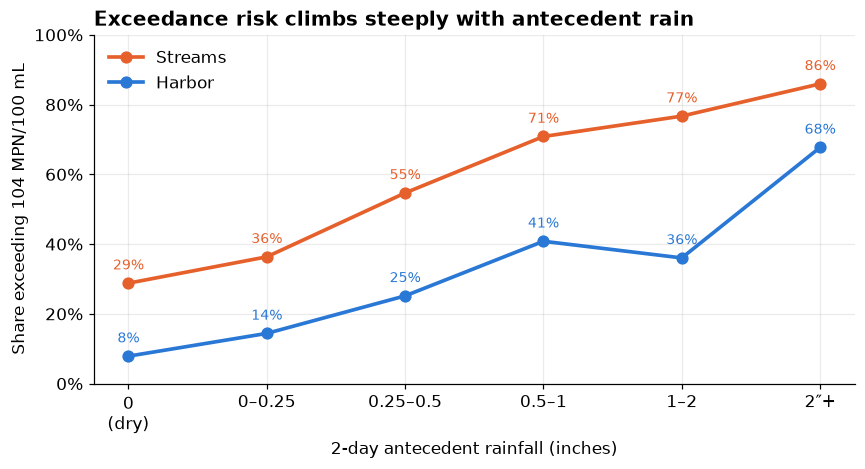

Spearman ρ(2-day rain, Enterococcus) — Streams: 0.347
Spearman ρ(2-day rain, Enterococcus) — Harbor: 0.279


In [4]:
from scipy.stats import spearmanr
bins = [-0.01, 0.01, 0.25, 0.5, 1.0, 2.0, 99]
labs = ["0\n(dry)", "0–0.25", "0.25–0.5", "0.5–1", "1–2", "2″+"]

fig, ax = plt.subplots(figsize=(8, 4.4))
rows = []
for name, df, color in [("Streams", nontidal, STREAM), ("Harbor", tidal, HARBOR)]:
    d = df[df["entero"].notna()].copy()
    d["exc"] = (d["entero"] > THRESH).astype(int)
    d["b"]   = pd.cut(pd.to_numeric(d["prcp_0_1d"], errors="coerce"), bins=bins, labels=labs)
    g = d.groupby("b", observed=True)["exc"].agg(["mean", "count"])
    ax.plot(range(len(g)), g["mean"]*100, "-o", color=color, lw=2.4, ms=7, label=name)
    for i, (m, n) in enumerate(zip(g["mean"], g["count"])):
        ax.annotate(f"{m*100:.0f}%", (i, m*100), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=9, color=color)
    rho = spearmanr(pd.to_numeric(d["prcp_0_1d"], errors="coerce"), d["entero"], nan_policy="omit").correlation
    rows.append((name, rho))
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs)
ax.set_ylabel("Share exceeding 104 MPN/100 mL"); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("2-day antecedent rainfall (inches)")
ax.set_title("Exceedance risk climbs steeply with antecedent rain", loc="left", fontweight="bold")
ax.legend(frameon=False); plt.tight_layout(); plt.show()
for name, rho in rows:
    print(f"Spearman ρ(2-day rain, Enterococcus) — {name}: {rho:.3f}")

## 5 · Define the feature sets

The experiment isolates the marginal value of rainfall by comparing four nested feature sets against the **same**
model and the **same** folds:

| Set | Contents | Question it answers |
|---|---|---|
| **M0 Context** | season (sin/cos month), station location, site dummies | how far do time & place alone go? |
| **M1 + In-situ WQ** | context **+** the lab/sonde panel | the *baseline* — the "prior" water-quality model |
| **M2 + Rainfall** | context + in-situ WQ **+** rainfall | **does rainfall add lift over the baseline?** |
| **M3 Rainfall only** | context **+** rainfall (no lab chemistry) | can we predict from weather alone (real-time / lab-free)? |

In [5]:
def add_context(df):
    df = df.copy()
    df["month"] = df["date"].dt.month
    df["msin"]  = np.sin(2*np.pi*df["month"]/12)
    df["mcos"]  = np.cos(2*np.pi*df["month"]/12)
    df["year"]  = df["date"].dt.year
    for pfx in sorted(df["prefix"].dropna().unique()):
        df[f"site_{pfx}"] = (df["prefix"] == pfx).astype(int)
    return df

tidal, nontidal = add_context(tidal), add_context(nontidal)

CONTEXT = ["msin", "mcos", "Latitude", "Longitude"]
INSITU = {
 "nontidal": ["Nitrate/Nitrite (mg/L)","Total Nitrogen (mg/L)","Total Phosphorus (mg/L)",
              "Total Kjeldahl Nitrogen (mg/L)","Dissolved Oxygen (mg/L)","Barometric Pressure (mmHg)",
              "Temperature (°C)","Specific Conductance (µS/cm)","pH (SU)","Turbidity (NTU)",
              "Optical Brighteners (ppm)"],
 "tidal":    ["Total Water Depth (ft)","Nitrate/Nitrite (mg/L)","Total Nitrogen (mg/L)",
              "Total Phosphorus (mg/L)","Total Kjeldahl Nitrogen (mg/L)","Chlorophyll (µg/L)",
              "Secchi Depth (m)"],
}
def feature_sets(kind):
    insitu = INSITU[kind]
    return {
        "M0 Context":       CONTEXT,
        "M1 + In-situ WQ":  CONTEXT + insitu,
        "M2 + Rainfall":    CONTEXT + insitu + RAIN_FEATURES,
        "M3 Rainfall only": CONTEXT + RAIN_FEATURES,
    }
print("Nontidal in-situ predictors:", len(INSITU["nontidal"]),
      "| Tidal in-situ predictors:", len(INSITU["tidal"]))

Nontidal in-situ predictors: 11 | Tidal in-situ predictors: 7


## 6 · The evaluation engine — year-blocked cross-validation

Samples collected on the same day share the same rainfall, so a *random* train/test split would leak weather
across folds and **inflate** any rainfall effect. We instead use **`GroupKFold` blocked by calendar year**: whole
years are held out, so no rain-day is ever in both train and test. Every metric below is **out-of-fold**.

Two tasks are scored on the same folds:
- **Regression** — predict $\log_{10}(\text{Enterococcus}+1)$ → **R²**, **RMSE** (log units)
- **Classification** — exceedance above 104 MPN/100 mL → **ROC-AUC**, **PR-AUC**

Site dummies are always appended. Missing predictors are median-imputed using **training-fold** statistics only.

In [6]:
def evaluate(df, feats, model="rf", n_splits=5, seed=RANDOM_STATE):
    d = df[df["entero"].notna()].copy()
    site_cols = [c for c in d.columns if c.startswith("site_")]
    cols = feats + site_cols
    X = d[cols].apply(lambda c: pd.to_numeric(c, errors="coerce")).astype(float).values
    y_reg = np.log10(d["entero"].values + 1.0)
    y_cls = (d["entero"].values > THRESH).astype(int)
    groups = d["year"].values

    def make(kind):
        if model == "rf":
            reg = RandomForestRegressor(300, min_samples_leaf=3, n_jobs=-1, random_state=seed)
            clf = RandomForestClassifier(300, min_samples_leaf=3, n_jobs=-1, random_state=seed,
                                         class_weight="balanced")
        elif model == "gb":
            reg = GradientBoostingRegressor(random_state=seed)
            clf = GradientBoostingClassifier(random_state=seed)
        else:  # linear / logistic, standardized + imputed
            reg = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0))
            clf = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                LogisticRegression(max_iter=2000, class_weight="balanced"))
        return reg if kind == "reg" else clf

    gkf = GroupKFold(n_splits=n_splits)
    oof_reg = np.full(len(d), np.nan); oof_p = np.full(len(d), np.nan)
    for tr, te in gkf.split(X, y_reg, groups):
        if model in ("rf", "gb"):   # tree models: explicit median impute (train-fold only)
            med = np.nanmedian(X[tr], axis=0); med = np.where(np.isnan(med), 0, med)
            Xtr = np.where(np.isnan(X[tr]), med, X[tr]); Xte = np.where(np.isnan(X[te]), med, X[te])
        else:
            Xtr, Xte = X[tr], X[te]  # pipeline imputes internally
        oof_reg[te] = make("reg").fit(Xtr, y_reg[tr]).predict(Xte)
        oof_p[te]   = make("clf").fit(Xtr, y_cls[tr]).predict_proba(Xte)[:, 1]
    return dict(n=len(d), exc_rate=y_cls.mean(),
                R2=r2_score(y_reg, oof_reg),
                RMSE=np.sqrt(mean_squared_error(y_reg, oof_reg)),
                AUC=roc_auc_score(y_cls, oof_p),
                PR_AUC=average_precision_score(y_cls, oof_p),
                oof_reg=oof_reg, oof_p=oof_p, y_reg=y_reg, y_cls=y_cls)

print("evaluate() ready")

evaluate() ready


## 7 · Model comparison — the core result

Random Forest across all four feature sets, both water bodies.

In [7]:
def comparison_table(df, kind, model="rf"):
    rows = {}
    for name, feats in feature_sets(kind).items():
        m = evaluate(df, feats, model=model)
        rows[name] = m
    tab = pd.DataFrame({k: {"R²": v["R2"], "RMSE": v["RMSE"], "AUC": v["AUC"], "PR-AUC": v["PR_AUC"]}
                        for k, v in rows.items()}).T
    return tab.round(3), rows

tab_nt, res_nt = comparison_table(nontidal, "nontidal")
tab_t,  res_t  = comparison_table(tidal,    "tidal")

def lift(tab):
    b, a = tab.loc["M1 + In-situ WQ"], tab.loc["M2 + Rainfall"]
    return a - b

print("NONTIDAL STREAMS  (Gwynns Falls + Jones Falls)  — exceedance base rate "
      f"{res_nt['M1 + In-situ WQ']['exc_rate']:.1%}, n={res_nt['M1 + In-situ WQ']['n']}")
display(tab_nt)
print("Rainfall lift over baseline:", dict(lift(tab_nt).round(3)))

print("\nTIDAL HARBOR  (Patapsco)  — exceedance base rate "
      f"{res_t['M1 + In-situ WQ']['exc_rate']:.1%}, n={res_t['M1 + In-situ WQ']['n']}")
display(tab_t)
print("Rainfall lift over baseline:", dict(lift(tab_t).round(3)))

NONTIDAL STREAMS  (Gwynns Falls + Jones Falls)  — exceedance base rate 40.1%, n=3561


,R²,RMSE,AUC,PR-AUC
M0 Context,0.082,0.973,0.681,0.581
M1 + In-situ WQ,0.311,0.843,0.827,0.752
M2 + Rainfall,0.310,0.843,0.829,0.758
M3 Rainfall only,0.203,0.906,0.762,0.659


Rainfall lift over baseline: {'R²': np.float64(-0.001), 'RMSE': np.float64(0.0), 'AUC': np.float64(0.002), 'PR-AUC': np.float64(0.006)}

TIDAL HARBOR  (Patapsco)  — exceedance base rate 16.1%, n=3581


,R²,RMSE,AUC,PR-AUC
M0 Context,0.171,0.903,0.708,0.320
M1 + In-situ WQ,0.197,0.889,0.738,0.343
M2 + Rainfall,0.356,0.796,0.844,0.553
M3 Rainfall only,0.370,0.788,0.842,0.572


Rainfall lift over baseline: {'R²': np.float64(0.159), 'RMSE': np.float64(-0.093), 'AUC': np.float64(0.106), 'PR-AUC': np.float64(0.21)}


**Read it as:** in the **streams**, M2 (＋rainfall) is statistically indistinguishable from M1 — rainfall adds
nothing on top of the chemistry. In the **harbor**, rainfall lifts every metric substantially, and M3 (rainfall
*only*, no lab chemistry) is essentially as good as the full model.

### 8 · Visualizing the comparison

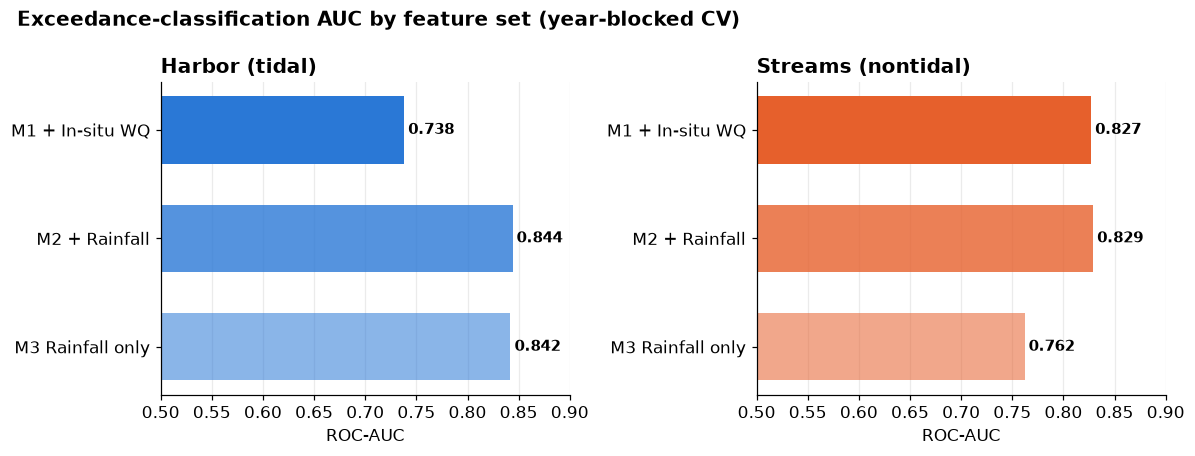

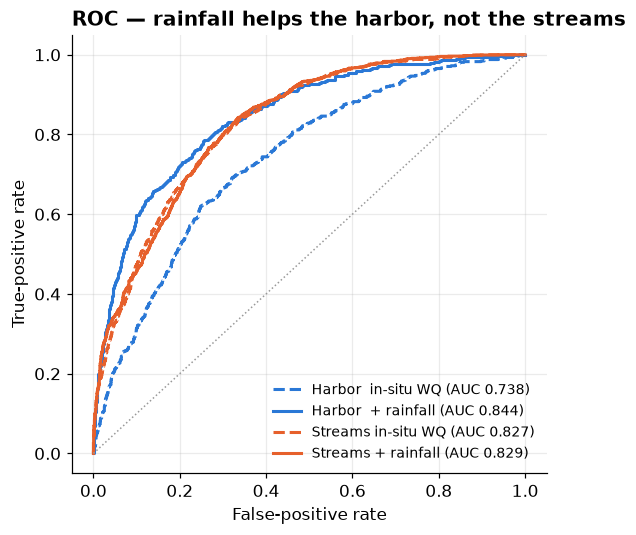

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, tab, kind, color in [(axes[0], tab_t, "Harbor (tidal)", HARBOR),
                             (axes[1], tab_nt, "Streams (nontidal)", STREAM)]:
    order = ["M1 + In-situ WQ", "M2 + Rainfall", "M3 Rainfall only"]
    vals = tab.loc[order, "AUC"]
    for i, (v, a) in enumerate(zip(vals, [1.0, 0.8, 0.55])):
        ax.barh(i, v, color=color, alpha=a, height=.62)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
    ax.invert_yaxis(); ax.set_xlim(0.5, 0.9)
    for i, v in enumerate(vals):
        ax.text(v + .004, i, f"{v:.3f}", va="center", fontsize=10, fontweight="bold")
    ax.set_title(kind, loc="left", fontweight="bold"); ax.set_xlabel("ROC-AUC")
    ax.grid(axis="y", alpha=0)
fig.suptitle("Exceedance-classification AUC by feature set (year-blocked CV)",
             x=.02, ha="left", fontweight="bold"); plt.tight_layout(); plt.show()

# ROC curves: baseline vs +rainfall, harbor
fig, ax = plt.subplots(figsize=(5.2, 5))
for label, m, c, ls in [("Harbor  in-situ WQ", res_t["M1 + In-situ WQ"], HARBOR, "--"),
                        ("Harbor  + rainfall",  res_t["M2 + Rainfall"],  HARBOR, "-"),
                        ("Streams in-situ WQ", res_nt["M1 + In-situ WQ"], STREAM, "--"),
                        ("Streams + rainfall",  res_nt["M2 + Rainfall"],  STREAM, "-")]:
    fpr, tpr, _ = roc_curve(m["y_cls"], m["oof_p"])
    ax.plot(fpr, tpr, ls, color=c, lw=2, label=f"{label} (AUC {m['AUC']:.3f})")
ax.plot([0,1],[0,1], color="#999", lw=1, ls=":")
ax.set_xlabel("False-positive rate"); ax.set_ylabel("True-positive rate")
ax.set_title("ROC — rainfall helps the harbor, not the streams", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="lower right"); plt.tight_layout(); plt.show()

## 9 · Why the split? Feature importance

Random-Forest impurity importance on the full (M2) feature set explains the divergence: rainfall is the top single
predictor in **both** water bodies, but in the streams the chemistry (phosphorus, DO, turbidity) sits right behind
it, capturing the same storm pulse a second way — so removing rainfall barely hurts.

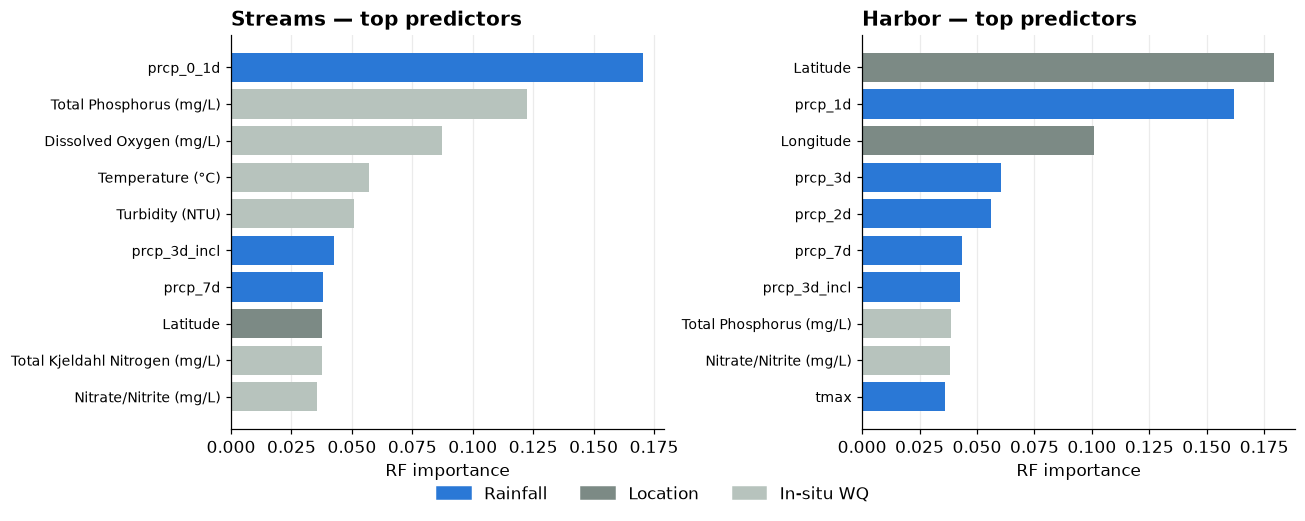

In [9]:
def importances(df, kind, top=12):
    d = df[df["entero"].notna()].copy()
    site_cols = [c for c in d.columns if c.startswith("site_")]
    cols = feature_sets(kind)["M2 + Rainfall"] + site_cols
    X = d[cols].apply(lambda c: pd.to_numeric(c, errors="coerce")).astype(float)
    X = X.fillna(X.median())
    y = np.log10(d["entero"].values + 1)
    rf = RandomForestRegressor(400, min_samples_leaf=3, n_jobs=-1,
                               random_state=0).fit(X, y)
    return pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False).head(top)

def kindof(name):
    if name.startswith("prcp") or name == "dry_days" or name == "tmax": return HARBOR  # rainfall
    if name.startswith("site_") or name in ("Latitude","Longitude"):    return SITE     # location
    return NEUTRAL

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (kind, title) in zip(axes, [("nontidal","Streams — top predictors"),
                                     ("tidal","Harbor — top predictors")]):
    imp = importances(df={"nontidal":nontidal,"tidal":tidal}[kind], kind=kind, top=10)[::-1]
    ax.barh(range(len(imp)), imp.values, color=[kindof(i) for i in imp.index])
    ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=9)
    ax.set_title(title, loc="left", fontweight="bold"); ax.set_xlabel("RF importance")
    ax.grid(axis="y", alpha=0)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=HARBOR, label="Rainfall"), Patch(color=SITE, label="Location"),
                    Patch(color=NEUTRAL, label="In-situ WQ")],
           frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(.5, -.04))
plt.tight_layout(); plt.show()

## 10 · Robustness — is the lift real or a lucky fold?

Repeat the M1-vs-M2 comparison across random seeds and also with a **Gradient Boosting** model. A stable,
near-zero lift in the streams and a stable, large lift in the harbor confirm the finding is structural, not an
artifact of one split or one estimator.

In [10]:
def lift_stability(df, kind, seeds=(0, 1, 2)):
    fs = feature_sets(kind)
    out = {}
    for model in ["rf", "gb"]:
        dr, da = [], []
        for s in seeds:
            b = evaluate(df, fs["M1 + In-situ WQ"], model=model, seed=s)
            a = evaluate(df, fs["M2 + Rainfall"],   model=model, seed=s)
            dr.append(a["R2"] - b["R2"]); da.append(a["AUC"] - b["AUC"])
        out[model] = (np.mean(dr), np.std(dr), np.mean(da), np.std(da))
    return out

for kind, name in [("tidal", "Harbor"), ("nontidal", "Streams")]:
    st = lift_stability({"tidal":tidal,"nontidal":nontidal}[kind], kind)
    print(f"\n{name} — rainfall lift (M2 − M1):")
    for model, (mdr, sdr, mda, sda) in st.items():
        print(f"   {model.upper():3s}:  ΔR² = {mdr:+.3f} ± {sdr:.3f}   ΔAUC = {mda:+.3f} ± {sda:.3f}")


Harbor — rainfall lift (M2 − M1):
   RF :  ΔR² = +0.158 ± 0.002   ΔAUC = +0.104 ± 0.001
   GB :  ΔR² = +0.150 ± 0.001   ΔAUC = +0.077 ± 0.001



Streams — rainfall lift (M2 − M1):
   RF :  ΔR² = -0.007 ± 0.001   ΔAUC = +0.003 ± 0.002
   GB :  ΔR² = -0.022 ± 0.001   ΔAUC = +0.000 ± 0.000


## 11 · Streamflow — ready to run when the daily data arrives

**Status: not yet tested.** The supplied `usgs_discharge_summary.csv` is a **3-row per-gauge summary**
(min/median/max), not the ~4,383 **daily** discharge values it references, and the live USGS NWIS API is blocked
in this environment. Herring Run is not in the bacteria workbook, so streamflow can only ever join the
**Gwynns + Jones** stream stations.

The cell below prints exactly what's in the summary file, then defines a `run_with_streamflow()` function that
plugs the real daily series straight into the same comparison. **To use it:** supply a daily table with columns
`site_no, date, discharge_cfs` for `01589300` (Gwynns) and `01589440` (Jones), set `STREAMFLOW_DAILY` to its path,
and run.

In [11]:
print("Contents of the supplied USGS file (a summary, not a daily series):")
display(pd.read_csv(USGS))

GAUGE_TO_PREFIX = {1589300: "BWB-GWN", 1589440: "BWB-JON"}   # 01585219 Herring Run: no bacteria data
STREAMFLOW_DAILY = None   # <-- set to a CSV path: columns site_no, date, discharge_cfs

def build_flow_features(daily):
    # daily: DataFrame[site_no, date, discharge_cfs] -> per-prefix antecedent-flow features.
    daily = daily.copy()
    daily["date"]   = pd.to_datetime(daily["date"]).dt.normalize()
    daily["prefix"] = daily["site_no"].astype(int).map(GAUGE_TO_PREFIX)
    parts = []
    for pfx, g in daily.dropna(subset=["prefix"]).groupby("prefix"):
        g = g.sort_values("date").set_index("date")
        q = pd.to_numeric(g["discharge_cfs"], errors="coerce")
        idx = pd.date_range(q.index.min(), q.index.max(), freq="D")
        q = q.reindex(idx).interpolate()
        f = pd.DataFrame(index=idx)
        f["q_0d"]   = q
        f["q_1d"]   = q.shift(1)
        f["q_3d"]   = q.rolling(3).mean().shift(1)
        f["q_7d"]   = q.rolling(7).mean().shift(1)
        f["logq"]   = np.log10(q + 1)
        f["q_rise"] = q - q.shift(1)                 # rising limb = fresh runoff
        f["prefix"] = pfx; f = f.reset_index(names="date")
        parts.append(f)
    return pd.concat(parts, ignore_index=True)

FLOW_FEATURES = ["q_0d","q_1d","q_3d","q_7d","logq","q_rise"]

def run_with_streamflow(path=STREAMFLOW_DAILY):
    if path is None:
        print("No daily streamflow supplied — set STREAMFLOW_DAILY to a CSV path and re-run.")
        return
    flow = build_flow_features(pd.read_csv(path))
    df = nontidal.merge(flow, on=["date","prefix"], how="left")
    fs = feature_sets("nontidal")
    base = fs["M2 + Rainfall"]                       # already best stream set
    variants = {
        "M2 in-situ+rain (baseline)": base,
        "+ Streamflow":              base + FLOW_FEATURES,
        "Rain + Flow only (no WQ)":  CONTEXT + RAIN_FEATURES + FLOW_FEATURES,
    }
    rows = {name: evaluate(df, feats) for name, feats in variants.items()}
    tab = pd.DataFrame({k: {"R²": v["R2"], "AUC": v["AUC"], "PR-AUC": v["PR_AUC"]}
                        for k, v in rows.items()}).T.round(3)
    print("Streams — effect of adding daily streamflow:"); display(tab)
    return tab

run_with_streamflow()

Contents of the supplied USGS file (a summary, not a daily series):


,usgs_site_no,site_name,watershed,matched_bwb_prefix,start_date,end_date,n_records,missing_discharge_values,min_discharge_cfs,median_note,max_discharge_cfs,qualification_codes_present,source_file
0,1589300,"GWYNNS FALLS AT VILLA NOVA, MD",Gwynns Falls,BWB-GWN,1/1/2013,12/31/2024,4383,0,5.45,calculated externally if needed,2460,A;A:e,USGSwaterservices.usgs.gov.txt
1,1589440,"JONES FALLS AT SORRENTO, MD",Jones Falls,BWB-JON,1/1/2013,12/31/2024,4383,0,5.97,calculated externally if needed,2020,A;A:R;A:e,USGS_waterservices.usgs.gov.txt
2,1585219,"HERRING RUN AT SINCLAIR LANE AT BALTIMORE, MD",Herring Run,BWB-HR,10/1/2013,12/31/2024,4110,0,5.44,calculated externally if needed,1290,A;A:R;A:e,usgs_-waterservices.usgs.gov.txt


No daily streamflow supplied — set STREAMFLOW_DAILY to a CSV path and re-run.


## 12 · Conclusions

1. **Rainfall is a strong physical driver of exceedance in both water bodies** — stream exceedance rises from
   ~29% on dry days to ~86% after 2″+ of antecedent rain; the harbor from ~8% to ~68%.

2. **As a *model* feature, rainfall's value depends on what the model already sees:**
   - **Tidal harbor — large, robust lift** (AUC 0.74 → 0.84, R² 0.20 → 0.36). The tidal data sheet lacks
     turbidity/temperature/conductance, so rainfall fills a real gap. A **rainfall-only** model nearly matches the
     full one — useful for real-time, lab-free nowcasting of harbor swimming risk.
   - **Nontidal streams — essentially no lift** (ΔAUC ≈ 0). In-situ turbidity, phosphorus and DO already encode the
     storm signal, so rainfall is redundant *on top of them* — though rainfall alone still reaches AUC ≈ 0.76.

3. **Practical takeaway:** add rainfall wherever the in-situ chemistry is thin or unavailable (the harbor, and any
   forecasting use case). Where a full stream chemistry panel exists, rainfall mostly confirms what turbidity
   already says.

4. **Streamflow is pending daily data.** Expectation by analogy: a strong standalone predictor, but likely
   redundant with the streams' existing chemistry. Section 11 runs the moment the daily discharge series is supplied.

**Caveats.** The harbor's larger lift partly reflects a *thinner* in-situ baseline; the fairest apples-to-apples
test is the streams. A single regional gauge (BWI) cannot capture localized convective storms. The 104 MPN/100 mL
threshold is the single-sample recreational criterion — swap in the freshwater STV (130) or a geomean rule as
needed (change `THRESH`).